# Regression from scratch

## Imports

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub # for loading dataset
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split

## Load Dataset

In [41]:
file_path = 'Salary_dataset.csv'
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abhishek14398/salary-dataset-simple-linear-regression",
    file_path
)

C:\Users\ArunShrestha\AppData\Local\Temp\ipykernel_8968\2505607900.py:2: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


In [42]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [43]:
x = df['YearsExperience'].values.reshape(-1, 1)
y = df['Salary'].values.reshape(-1, 1)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

# print data shapes
x_train.shape, y_train.shape

((24, 1), (24, 1))

## Model Definition (From Scratch)

In [44]:
class LinearRegression:
    def __init__(self):
        self.weights = None
        self.loss_history = []
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def MSE(self, y_pred, y):
        return np.mean((y - y_pred) ** 2)
    
    def normalize_data(self, X, y):
        self.X_mean = np.mean(X, axis=0)
        self.X_std = np.std(X, axis=0)
        # Normalize
        x_normalized = (X - self.X_mean) / self.X_std

        self.y_mean = np.mean(y, axis=0)
        self.y_std = np.std(y, axis=0)
        y_normalized = (y - self.y_mean) / self.y_std

        return x_normalized, y_normalized
    
    def train(self, X, y, lr, epochs, normalized=True):
        # Normalize data if asked
        if normalized:
            X, y = self.normalize_data(X, y)

        # Add dummy input x = 1 for bias 
        X_with_bias = np.hstack((np.ones((X.shape[0], 1)), X))

        # Initialize weights (bias + feature weight)
        self.weights = np.zeros((X_with_bias.shape[1], 1))

        # Training Loop
        for epoch in range(epochs):
            # Forward pass
            y_pred = np.dot(X_with_bias, self.weights)

            # calculate loss
            loss = self.MSE(y_pred, y)
            self.loss_history.append(loss)

            # Backward pass
            m = y.shape[0]
            error = y_pred - y

            # calculte gradients
            gradients = np.dot(X_with_bias.T, error) / m

            self.weights -= lr * gradients

            # print Progress
            if epoch % 100 == 0:
                print(f"Epoch {epoch} / {epochs}: Loss = {loss:.6f}")

        print('\n\nTraining Completed')


    def predict(self, X, denormalize = True):
        if self.weights is None:
            print("Model not trained yet")

        # normalize input if model was trained with normalization
        if denormalize and self.X_mean is not None:
            X_norm = (X - self.X_mean) / self.X_std
        else:
            X_norm = X

        # add dummy input for bias (x = 1)
        X_with_bias = np.hstack((np.ones((X_norm.shape[0], 1)), X_norm))

        # make prediction
        predictions = np.dot(X_with_bias, self.weights)

        # denormalize predictions if requested
        if denormalize and self.y_mean is not None:
            predictions = predictions * self.y_std + self.y_mean

        return predictions

## Train the model

In [45]:
model = LinearRegression()
model.train(X=x_train, y=y_train, lr=0.01, epochs=500, normalized=True)

Epoch 0 / 500: Loss = 1.000000
Epoch 100 / 500: Loss = 0.164689
Epoch 200 / 500: Loss = 0.052774
Epoch 300 / 500: Loss = 0.037780
Epoch 400 / 500: Loss = 0.035771


Training Completed


## Make Prediction

In [46]:
predictions = model.predict(x_test, denormalize=True)

## Evaluation

In [47]:
def print_error(error, value):
    print(f"{error}: {value}")


MAE = np.mean(abs(y_test - predictions))
R_square = 1 - (np.sum((y_test - predictions) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
MSE_loss = model.MSE(y_test, predictions)
R_MSE_loss = np.sqrt(MSE_loss)
MAPE = np.mean(np.abs((y_test - predictions) / np.where(y_test != 0, y_test, 1))) * 100

print("Coefficient: ", model.weights[1])
print("Bias: ", model.weights[0])
print_error("MAE", MAE)
print_error("R_square", R_square)
print_error("MSE_loss", MSE_loss)
print_error("R_MSE_loss", R_MSE_loss)
print_error("MAPE", MAPE)

Coefficient:  [0.97565712]
Bias:  [2.1582273e-16]
MAE: 6270.974076064039
R_square: 0.9020629066844771
MSE_loss: 50025869.99191149
R_MSE_loss: 7072.896859979756
MAPE: 7.7324459651314985


## Visualization

Intercept (bias): [2.1582273e-16]
Slope (coefficient): [0.97565712]


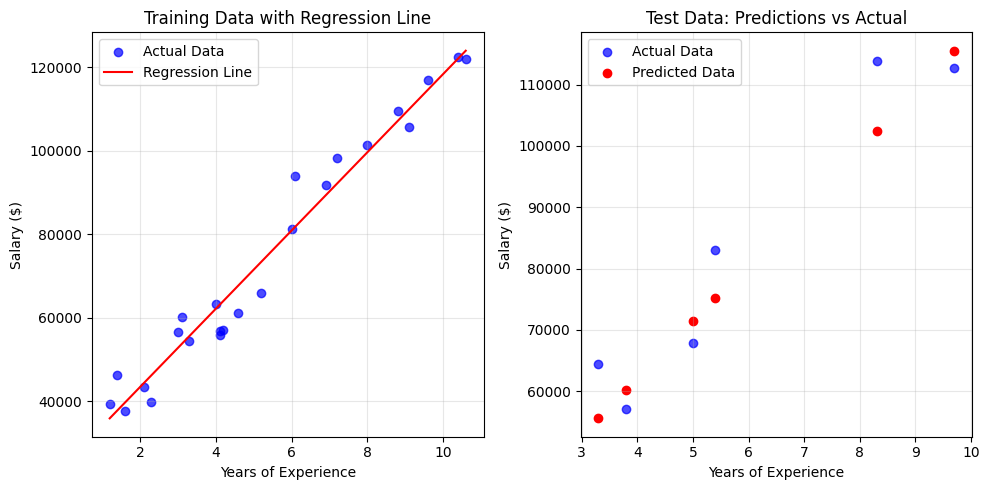

In [48]:
print("Intercept (bias):", model.weights[0])
print("Slope (coefficient):", model.weights[1])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(x_train, y_train, alpha=0.7, color="blue", label='Actual Data')

# Use model predictions to get the correct regression line
# Sort x_train for smooth line plotting
sorted_indices = np.argsort(x_train.flatten())
x_train_sorted = x_train[sorted_indices]
y_train_pred = model.predict(x_train_sorted, denormalize=True)

plt.plot(x_train_sorted.flatten(), y_train_pred.flatten(), color='red', label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary ($)")
plt.title("Training Data with Regression Line")
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1,2,2)
plt.scatter(x_test, y_test, alpha=0.7, color="blue", label='Actual Data')
plt.scatter(x_test, predictions, color='red', label="Predicted Data")
plt.xlabel("Years of Experience")
plt.ylabel("Salary ($)")
plt.title("Test Data: Predictions vs Actual")
plt.legend()
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

## Loss Visualization

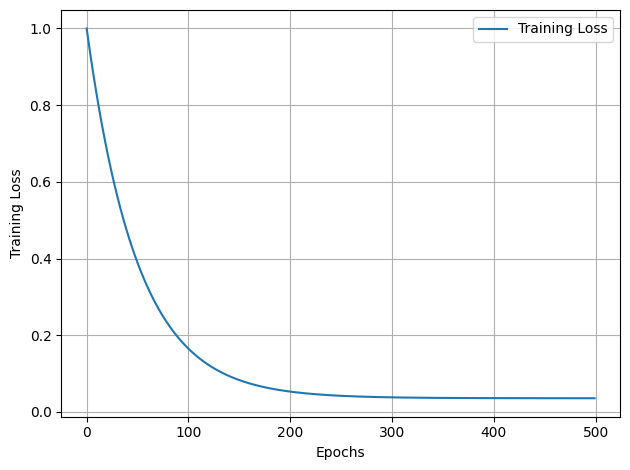

In [49]:
plt.plot(model.loss_history, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()

plt.grid(True)
plt.tight_layout()

# Using Scikit-Learn

## Imports

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

## Load Dataset

In [51]:
file_path = 'Salary_dataset.csv'
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abhishek14398/salary-dataset-simple-linear-regression",
    file_path
)

C:\Users\ArunShrestha\AppData\Local\Temp\ipykernel_8968\2505607900.py:2: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


In [52]:
X = df['YearsExperience'].values.reshape(-1, 1)
y = df['Salary'].values.reshape(-1, 1)

X.shape, y.shape


((30, 1), (30, 1))

## Train test split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Initialize and train the model

In [54]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [55]:
y_pred = model.predict(X_test)
y_pred

array([[115791.21011287],
       [ 71499.27809463],
       [102597.86866063],
       [ 75268.80422384],
       [ 55478.79204548],
       [ 60190.69970699]])

In [56]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [57]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(f"RMSE: {rmse:.3f}")
print(f"R2 Score: {r2:.3f}")

Coefficients: [[9423.81532303]]
Intercept: [24380.20147947]
RMSE: 7059.044
R2 Score: 0.902
